In [1]:
import re
import csv

def parse_mmlu_file(txt_file, output_csv):
    data = []
    with open(txt_file, 'r') as f:
        for line in f:
            match = re.search(r'\|\s*(.*?)\s*\|.*?\|([0-9.]+)\|±\s*\|([0-9.]+)\|', line)
            if match:
                category = match.group(1).strip('- ').strip().replace('_', ' ').title().replace('Mmlu', 'MMLU').replace('Stem', 'STEM')
                acc = float(match.group(2))
                se = float(match.group(3))
                data.append([category, acc, se])
    #data.sort()
    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['category', 'accuracy', 'std_error'])
        writer.writerows(data)

parse_mmlu_file("llama-mmlu.txt", "llama-mmlu.csv")
parse_mmlu_file("smileyllama-525-mmlu.txt", "smileyllama-525-mmlu.csv")
parse_mmlu_file("llama-base-mmlu.txt", "llama-base-mmlu.csv")

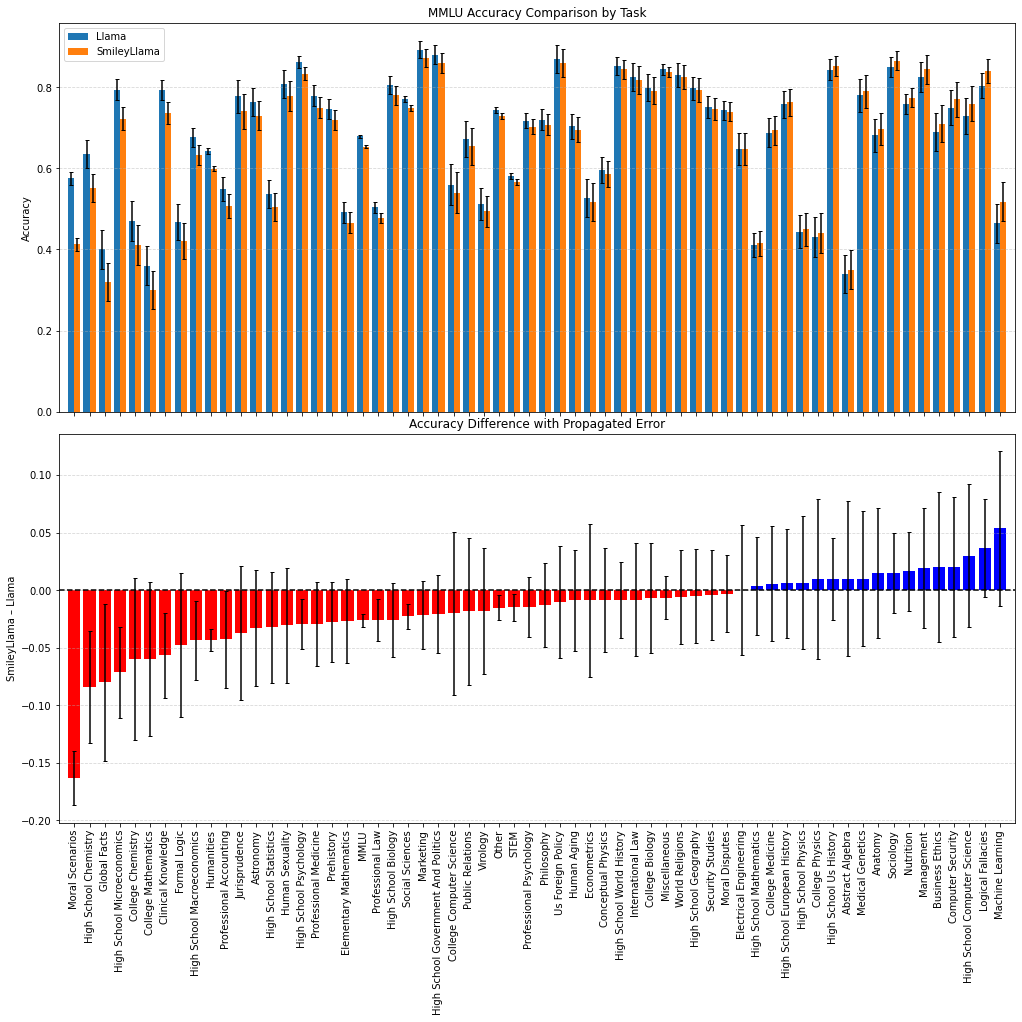

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df1 = pd.read_csv("llama-mmlu.csv")
df2 = pd.read_csv("smileyllama-525-mmlu.csv")
df3 = pd.read_csv("llama-base-mmlu.csv")

# Merge on category
merged = pd.merge(df1, df2, on='category', suffixes=('_model1', '_model2'))

# Sort by model1 accuracy or difference
merged['diff'] = merged['accuracy_model2'] - merged['accuracy_model1']
merged['se_diff'] = np.sqrt(merged['std_error_model1']**2 + merged['std_error_model2']**2)

# Sort by difference (optional)
merged = merged.sort_values(by='diff')

# X-axis positions
x = np.arange(len(merged))
width = 0.4

# Plot
fig, axs = plt.subplots(2, 1, figsize=(14, 14), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

# --- Top: Model 1 and Model 2 Accuracy ---
axs[0].bar(x - width/2, merged['accuracy_model1'], width, yerr=merged['std_error_model1'], label='Llama', capsize=2)
axs[0].bar(x + width/2, merged['accuracy_model2'], width, yerr=merged['std_error_model2'], label='SmileyLlama', capsize=2)
axs[0].set_ylabel("Accuracy")
axs[0].set_title("MMLU Accuracy Comparison by Task")
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
axs[0].margins(x=0.01)

# --- Middle: Difference ---
for i, (diff, se) in enumerate(zip(merged['diff'], merged['se_diff'])):
    color = 'blue' if diff > 0 else 'red'
    axs[1].bar(x[i], diff, yerr=se, capsize=2, color=color)

axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_ylabel("SmileyLlama – Llama")
axs[1].set_title("Accuracy Difference with Propagated Error")
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
axs[1].set_xticks(x)
axs[1].set_xticklabels(merged['category'], rotation=90, fontsize=10)
axs[1].margins(x=0.01)

plt.tight_layout(pad=0)
plt.savefig("mmlu_comparison.png", dpi=300, bbox_inches='tight')
plt.show()